# Sigma2 Stability Analysis

Same approach as sigma1 notebook, but for **sigma2** (ISIs 8, 16, 32, 64).

**Key challenge:** High ISIs need many stimuli per experiment.
`make_isi_n_block_experiment` requires `k >= ISI + 1`:
- ISI=8 → k≥9, ISI=16 → k≥17, ISI=32 → k≥33, ISI=64 → k≥65

| Section | Question |
|---------|----------|
| A | Per-ISI stability vs n_experiments |
| B | k_stimuli sensitivity per ISI |
| C | Combined-ISI stability |
| D | Which ISI subsets are most informative? (Can we drop ISI-64?) |

In [1]:
import sys, os, yaml, torch, random
import matplotlib.pyplot as plt, numpy as np, pandas as pd
from collections import defaultdict
from scipy.stats import norm
from sklearn.metrics import roc_auc_score
from pathlib import Path
from scipy.spatial.distance import pdist
from tqdm.notebook import trange, tqdm

sys.path.append('/om2/user/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/')

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set, texture_dataset
from texture_prior.utils import path
from utls.plotting import ensure_dir
from utls.loading import (load_results_with_exclusion_2, move_sequences_to_used,
                           load_results_with_exclusion_no_dropping)
from utls.runners_v2 import run_experiment_scores, make_noise_schedule
from utls.runners_utils import *
from encoders import *
from utls.toy_experiments import (
    make_isi_n_block_experiment, make_toy_experiment_list, make_multi_isi_toy_experiments,
)
from utls.sigma_fitting import log_mid, make_grid, auc_to_dprime


In [16]:
def load_config(cfg_path):
    cfg_path = Path(cfg_path)
    if not cfg_path.exists():
        raise FileNotFoundError(cfg_path)
    with open(cfg_path) as f:
        return yaml.safe_load(f), cfg_path

def median_pairwise_distance(X, metric="euclidean", n_samples=500, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=min(n_samples, X.shape[0]), replace=False)
    return float(np.median(pdist(X[idx], metric=metric)))

CONFIG_PATH = (
    "/om2/user/bjmedina/auditory-memory/memory/"
    "model_yamls/v14_three-stage-testing/run_000004.yaml"
)

model_cfg, model_cfg_path = load_config(CONFIG_PATH)
print(model_cfg)


{'results_root': '/om2/user/bjmedina/auditory-memory/memory', 'tag': 'slurm', 'experiment': {'is_multi': True, 'n_seqs': 36, 'n_samples': 50, 'which_task': 0}, 'metric': 'cosine', 'noise_model': {'name': 'three-regime', 'sigma0_min': 1.0, 'sigma0_max': 40.0, 'sigma1_min': 0.1, 'sigma1_max': 40.0, 'sigma2_min': 0.0005, 'sigma2_max': 20.0, 't_step': 5}, 'fitting': {'n_grid': 5, 'n_mc': 32, 'n_refine_iters': 4, 'n_experiments_per_isi': 5, 'k_stimuli_per_exp': 5}, 'run_id': 'run_000004', 'representation': {'type': 'resnet50', 'layer': 'layer4', 'time_avg': False}}


In [17]:
exp_cfg    = model_cfg["experiment"]
which_task = exp_cfg["which_task"]
is_multi   = exp_cfg["is_multi"]
which_isi  = exp_cfg.get("which_isi", None)
isis       = [0, 1, 2, 4, 8, 16, 32, 64] if is_multi else [0, which_isi]
metric     = model_cfg["metric"]
noise_cfg  = model_cfg["noise_model"]
noise_mode = noise_cfg["name"]
t_step     = noise_cfg["t_step"]
repr_cfg   = model_cfg["representation"]
time_avg   = repr_cfg["time_avg"]
encoder_type = repr_cfg["type"]
layer      = repr_cfg.get("layer", None)
pc_dims    = repr_cfg.get("pc_dims", None)

exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi, is_multi, old=False)
)
human_curve  = compute_human_curve(human_runs, is_multi, which_isi)
time_avg_tag = "time_avg" if time_avg else "nontime_avg"
print("ISIs:", isis)
print("Human d':", human_curve)


/om2/user/bjmedina/auditory-memory/memory/utls/runners_utils.py:209: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


ISIs: [0, 1, 2, 4, 8, 16, 32, 64]
Human d': [3.39193635 2.95940857 2.34008101 2.11665839 1.93263484 1.88249906
 1.75100596 1.55651236]


In [18]:
NN_ENCODERS  = {"kell2018", "resnet50"}
encoder_task = "word_speaker_audioset" if encoder_type in NN_ENCODERS else "audioset"
encoder_cfg  = dict(
    encoder_type=encoder_type, model_name=encoder_type, task=encoder_task,
    statistics_dict=statistics_set.statistics, model_params=model_params,
    pc_dims=pc_dims, sr=20000, duration=2.0, rms_level=0.05,
    time_avg=time_avg, device="cuda",
)
if encoder_type in NN_ENCODERS: encoder_cfg["layer"] = layer
if encoder_type == "texture":   encoder_cfg["pc_dims"] = pc_dims

encoder_name = make_encoder_name(encoder_cfg)
encoder      = build_encoder(encoder_cfg)
X            = encode_stimuli(encoder, all_files)
X_np         = X.detach().cpu().numpy()
print("Shape:", X_np.shape, " NaN?", torch.isnan(X).any().item())

d50 = median_pairwise_distance(X_np, metric="cosine")
print(f"d50 = {d50:.6f}")

param_bounds = {
    "sigma0": (noise_cfg["sigma0_min"],         noise_cfg["sigma0_max"]),
    "sigma1": (noise_cfg["sigma1_min"] * d50,   noise_cfg["sigma1_max"] * d50),
    "sigma2": (noise_cfg["sigma2_min"] * d50,   noise_cfg["sigma2_max"] * d50),
}
for k, v in param_bounds.items():
    print(f"  {k}: ({v[0]:.6f}, {v[1]:.6f})")

stimulus_pool = sorted({s for seq in exp_list for s in seq})
print(f"Stimulus pool: {len(stimulus_pool)}")


LOADING FROM /om2/user/bjmedina/models/cochdnn/model_directories/resnet50_word_speaker_audioset/
=> loading checkpoint '/om2/user/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt'
=> loaded checkpoint '/om2/user/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt' (epoch 6)
Shape: (80, 186368)  NaN? False
d50 = 0.479312
  sigma0: (1.000000, 40.000000)
  sigma1: (0.047931, 19.172478)
  sigma2: (0.000240, 9.586239)
Stimulus pool: 80


In [19]:
sigma0_fixed = 12#log_mid(*param_bounds['sigma0'])
sigma1_fixed = 3#log_mid(*param_bounds['sigma1'])
print(f'Fixed sigma0 = {sigma0_fixed:.6f}')
print(f'Fixed sigma1 = {sigma1_fixed:.6f}')

isi_to_hc_idx = {isi_val: i for i, isi_val in enumerate(isis)}
N_MC      = 64//4
N_PER_DIM = 2

sigma2_grid = make_grid(param_bounds['sigma2'][0],
                        param_bounds['sigma2'][1],
                        N_PER_DIM, spacing='log')
print('sigma2 grid:', [f'{v:.6f}' for v in sigma2_grid])

print('\nHuman d\' targets:')
for isi_val in [8, 16, 32, 64]:
    idx = isi_to_hc_idx.get(isi_val)
    if idx is not None:
        print(f'  ISI {isi_val}: {human_curve[idx]:.4f}')
    else:
        print(f'  ISI {isi_val}: NOT in isis list!')

print('\nMin k per ISI (pool size =', len(stimulus_pool), '):')
for isi in [8, 16, 32, 64]:
    print(f'  ISI {isi}: k >= {isi+1}')


Fixed sigma0 = 12.000000
Fixed sigma1 = 3.000000
sigma2 grid: ['0.000240', '9.586239']

Human d' targets:
  ISI 8: 1.9326
  ISI 16: 1.8825
  ISI 32: 1.7510
  ISI 64: 1.5565

Min k per ISI (pool size = 80 ):
  ISI 8: k >= 9
  ISI 16: k >= 17
  ISI 32: k >= 33
  ISI 64: k >= 65


In [20]:
def run_sigma_sweep(sigma_name, sigma_grid, fixed_sigmas, exps_by_isi,
                    isi_to_hc_idx, human_curve, N_MC, t_step, noise_mode,
                    metric, X, name_to_idx, base_seed=0):
    """Sweep one sigma over sigma_grid; for each value run N_MC reps.
    Returns list of dicts with sigma_value, mse_mean, mse_std, dprime_mean, dprime_std.
    """
    results = []
    for sig_idx, sigma_val in enumerate(sigma_grid):
        sigmas = dict(fixed_sigmas)
        sigmas[sigma_name] = sigma_val
        mse_per_rep    = []
        dprime_per_rep = []

        for rep in trange(N_MC, desc=f"{sigma_name}={sigma_val:.4g}", leave=False):
            rep_mse = []
            rep_dp  = []
            for isi_val, exps in exps_by_isi.items():
                if not exps: continue
                hc_idx   = isi_to_hc_idx.get(isi_val)
                if hc_idx is None: continue
                human_dp = human_curve[hc_idx]
                run_out  = run_experiment_scores(
                    sigma0=sigmas["sigma0"], sigma1=sigmas["sigma1"], sigma2=sigmas["sigma2"],
                    t_step=t_step, rate=0, noise_mode=noise_mode,
                    metric=metric, X0=X, name_to_idx=name_to_idx,
                    experiment_list=exps, debug=False,
                    seed=base_seed + isi_val*1_000_000 + sig_idx*10_000 + rep,
                )
                hits = np.asarray(run_out["hits"]); fas = np.asarray(run_out["fas"])
                if len(hits)==0 or len(fas)==0: continue
                y = np.concatenate([np.ones(len(hits)), np.zeros(len(fas))])
                dp = auc_to_dprime(roc_auc_score(y, -np.concatenate([hits,fas])))
                rep_mse.append((dp - human_dp)**2)
                rep_dp.append(dp)
            if rep_mse:
                mse_per_rep.append(np.mean(rep_mse))
                dprime_per_rep.append(np.mean(rep_dp))

        results.append({
            "sigma_value":  sigma_val,
            "mse_mean":     np.mean(mse_per_rep)    if mse_per_rep    else np.nan,
            "mse_std":      np.std(mse_per_rep)     if mse_per_rep    else np.nan,
            "dprime_mean":  np.mean(dprime_per_rep) if dprime_per_rep else np.nan,
            "dprime_std":   np.std(dprime_per_rep)  if dprime_per_rep else np.nan,
        })
    return results

## Section A: Per-ISI Stability

Each ISI tested independently. k_stimuli set to `ISI + 2` (minimum for one block).
Vary n_experiments in [20, 40, 80, 160].

In [21]:
EXP_COUNTS = [20, 40, ]
TEST_ISIS  = [8, 16, ]
per_isi_results = {}

for isi_val in TEST_ISIS:
    hc_idx = isi_to_hc_idx.get(isi_val)
    if hc_idx is None:
        print(f'ISI {isi_val} not in data — skip'); continue
    k_stim = min(isi_val + 2, len(stimulus_pool))
    print(f'\n=== ISI={isi_val} k={k_stim} human d\'={human_curve[hc_idx]:.4f} ===')
    n_exp_results = {}

    for n_exp in EXP_COUNTS:
        exps = make_toy_experiment_list(
            stimulus_pool, isi=isi_val, n_experiments=n_exp,
            k_stimuli=k_stim, seed=isi_val*1000+n_exp)
        exps = [e for e in exps if e]
        print(f'  n_exp={n_exp}: {len(exps)} exps, '
              f'avg len {np.mean([len(e) for e in exps]):.1f}' if exps else f'  n_exp={n_exp}: EMPTY')
        if not exps: continue

        res = run_sigma_sweep(
            sigma_name='sigma2', sigma_grid=sigma2_grid,
            fixed_sigmas={'sigma0': sigma0_fixed, 'sigma1': sigma1_fixed, 'sigma2': 0},
            exps_by_isi={isi_val: exps},
            isi_to_hc_idx=isi_to_hc_idx, human_curve=human_curve,
            N_MC=N_MC, t_step=t_step, noise_mode=noise_mode,
            metric=metric, X=X, name_to_idx=name_to_idx,
            base_seed=isi_val*100_000_000 + n_exp*1_000_000,
        )
        n_exp_results[n_exp] = res

    per_isi_results[isi_val] = n_exp_results
print('Done.')



=== ISI=8 k=10 human d'=1.9326 ===
  n_exp=20: 20 exps, avg len 18.0


sigma2=0.0002397:   0%|          | 0/16 [00:00<?, ?it/s]

sigma2=9.586:   0%|          | 0/16 [00:00<?, ?it/s]

  n_exp=40: 40 exps, avg len 18.0


sigma2=0.0002397:   0%|          | 0/16 [00:00<?, ?it/s]

...

sigma2=9.586:   0%|          | 0/16 [00:00<?, ?it/s]

  n_exp=40: 40 exps, avg len 34.0


sigma2=0.0002397:   0%|          | 0/16 [00:00<?, ?it/s]

sigma2=9.586:   0%|          | 0/16 [00:00<?, ?it/s]

Done.


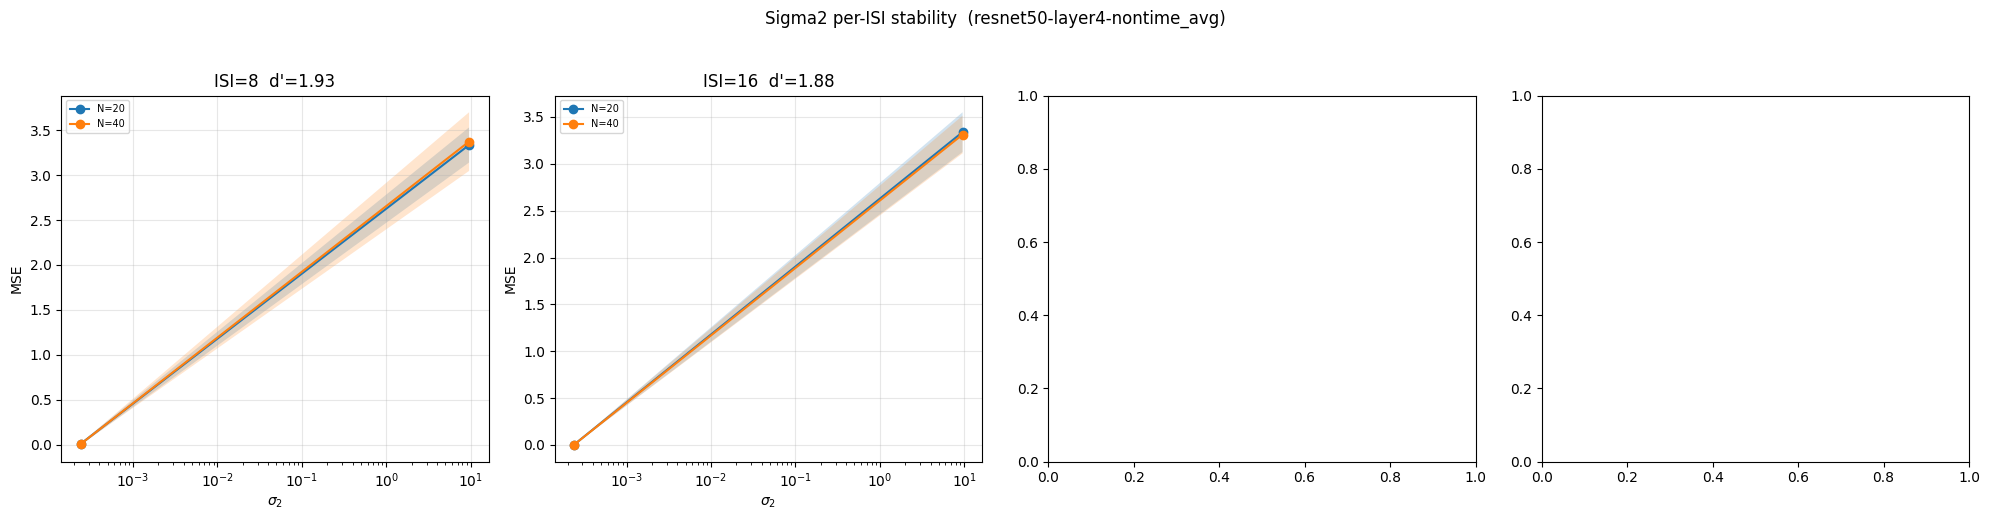

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, isi_val in zip(axes, TEST_ISIS):
    hc_idx = isi_to_hc_idx.get(isi_val)
    if hc_idx is None or isi_val not in per_isi_results:
        ax.set_title(f'ISI={isi_val} (skip)'); continue
    for n_exp, res in per_isi_results[isi_val].items():
        df = pd.DataFrame(res)
        ax.plot(df.sigma_value, df.mse_mean, 'o-', label=f'N={n_exp}')
        ax.fill_between(df.sigma_value, df.mse_mean-df.mse_std,
                        df.mse_mean+df.mse_std, alpha=0.2)
    ax.set_xscale('log'); ax.set_xlabel(r'$\sigma_2$'); ax.set_ylabel('MSE')
    ax.set_title(f'ISI={isi_val}  d\'={human_curve[hc_idx]:.2f}')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.suptitle(f'Sigma2 per-ISI stability  ({encoder_type}-{layer}-{time_avg_tag})', y=1.03)
plt.tight_layout(); plt.show()


## Section B: k_stimuli Sensitivity

Fixed n_exp=40. For each ISI, test k = ISI+1, ISI+5, 2*(ISI+1), 3*(ISI+1).
Shows how experiment length (more blocks) affects stability.

In [23]:
N_EXP_FOR_K = 40
k_sensitivity = {}   # isi -> {k -> list_of_result_dicts}

for isi_val in TEST_ISIS:
    hc_idx = isi_to_hc_idx.get(isi_val)
    if hc_idx is None: continue

    k_min = isi_val + 1
    k_candidates = sorted(set(
        min(k, len(stimulus_pool))
        for k in [k_min, k_min+5, 2*k_min, 3*k_min]
    ))
    print(f'\n=== ISI={isi_val}  k candidates: {k_candidates} ===')

    k_results = {}
    for k_stim in k_candidates:
        exps = make_toy_experiment_list(
            stimulus_pool, isi=isi_val, n_experiments=N_EXP_FOR_K,
            k_stimuli=k_stim, seed=isi_val*500+k_stim)
        exps = [e for e in exps if e]
        print(f'  k={k_stim}: {len(exps)} exps, '
              f'avg len {np.mean([len(e) for e in exps]):.1f}' if exps else f'  k={k_stim}: EMPTY')
        if not exps: continue

        res = run_sigma_sweep(
            sigma_name='sigma2', sigma_grid=sigma2_grid,
            fixed_sigmas={'sigma0': sigma0_fixed, 'sigma1': sigma1_fixed, 'sigma2': 0},
            exps_by_isi={isi_val: exps},
            isi_to_hc_idx=isi_to_hc_idx, human_curve=human_curve,
            N_MC=N_MC, t_step=t_step, noise_mode=noise_mode,
            metric=metric, X=X, name_to_idx=name_to_idx,
            base_seed=isi_val*200_000_000 + k_stim*1_000_000,
        )
        k_results[k_stim] = res

    k_sensitivity[isi_val] = k_results
print('Done.')



=== ISI=8  k candidates: [9, 14, 18, 27] ===
  k=9: 40 exps, avg len 18.0


sigma2=0.0002397:   0%|          | 0/16 [00:00<?, ?it/s]

sigma2=9.586:   0%|          | 0/16 [00:00<?, ?it/s]

  k=14: 40 exps, avg len 18.0


sigma2=0.0002397:   0%|          | 0/16 [00:00<?, ?it/s]

...

sigma2=9.586:   0%|          | 0/16 [00:00<?, ?it/s]

  k=51: 40 exps, avg len 102.0


sigma2=0.0002397:   0%|          | 0/16 [00:00<?, ?it/s]

sigma2=9.586:   0%|          | 0/16 [00:00<?, ?it/s]

Done.


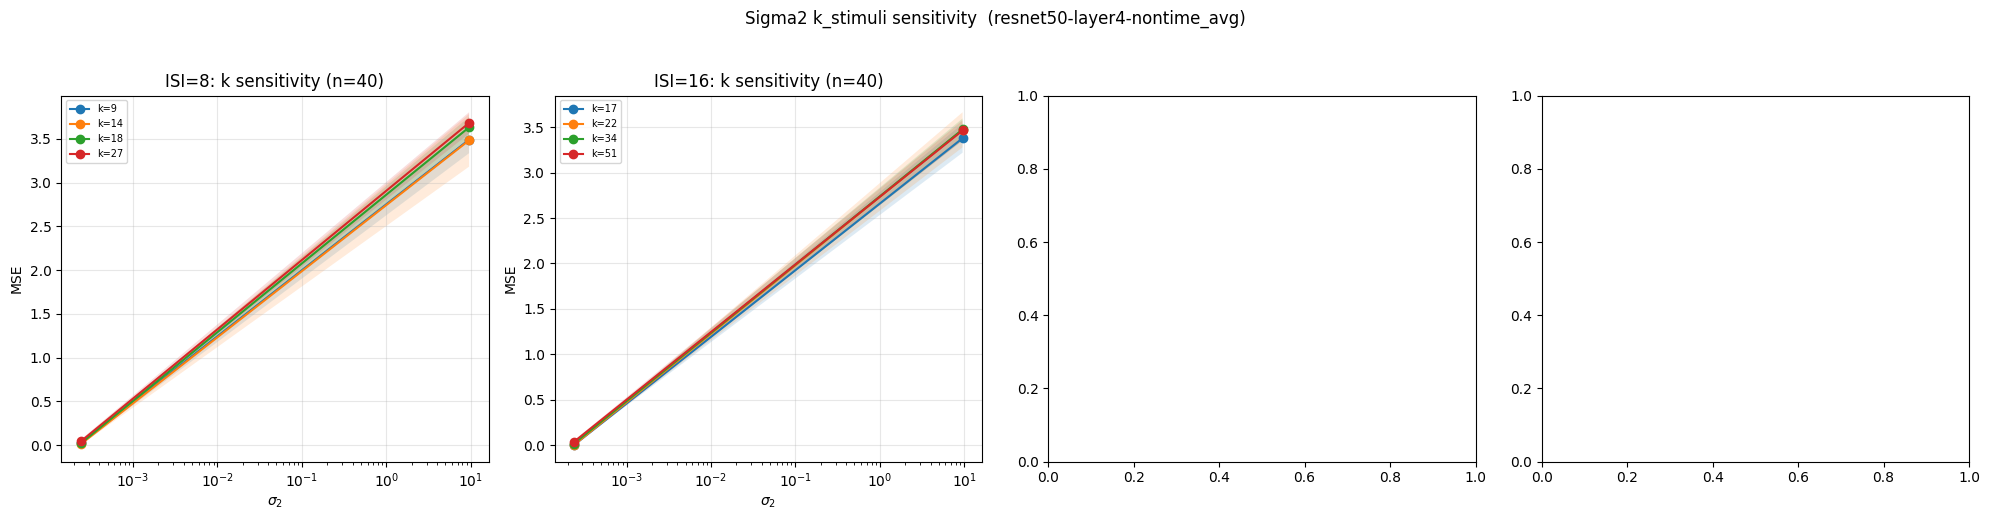

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, isi_val in zip(axes, TEST_ISIS):
    if isi_val not in k_sensitivity:
        ax.set_title(f'ISI={isi_val} (skip)'); continue
    for k_stim, res in k_sensitivity[isi_val].items():
        df = pd.DataFrame(res)
        ax.plot(df.sigma_value, df.mse_mean, 'o-', label=f'k={k_stim}')
        ax.fill_between(df.sigma_value, df.mse_mean-df.mse_std,
                        df.mse_mean+df.mse_std, alpha=0.15)
    ax.set_xscale('log'); ax.set_xlabel(r'$\sigma_2$'); ax.set_ylabel('MSE')
    ax.set_title(f'ISI={isi_val}: k sensitivity (n={N_EXP_FOR_K})')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.suptitle(f'Sigma2 k_stimuli sensitivity  ({encoder_type}-{layer}-{time_avg_tag})', y=1.03)
plt.tight_layout(); plt.show()


## Section C: Combined ISI Stability

All ISIs [8, 16, 32, 64] together. k_stimuli=70 (sufficient for ISI-64).

In [ ]:
COMBINED_ISIS      = [8, 16, 32, 64]
COMBINED_EXP_COUNTS = [20, 40]
K_COMBINED = min(70, len(stimulus_pool))
print(f'k_combined = {K_COMBINED}')
combined_results = {}

for n_exp in COMBINED_EXP_COUNTS:
    print(f'\n--- n_exp/ISI={n_exp} ---')
    exps_by_isi = make_multi_isi_toy_experiments(
        stimulus_pool, isi_values=COMBINED_ISIS,
        n_experiments_per_isi=n_exp, k_stimuli=K_COMBINED, seed=200+n_exp)
    for iv, el in exps_by_isi.items():
        el = [e for e in el if e]; exps_by_isi[iv] = el
        print(f'  ISI {iv}: {len(el)} exps, avg len {np.mean([len(e) for e in el]):.1f}' if el else f'  ISI {iv}: EMPTY')

    res = run_sigma_sweep(
        sigma_name='sigma2', sigma_grid=sigma2_grid,
        fixed_sigmas={'sigma0': sigma0_fixed, 'sigma1': sigma1_fixed, 'sigma2': 0},
        exps_by_isi={iv: el for iv, el in exps_by_isi.items() if el},
        isi_to_hc_idx=isi_to_hc_idx, human_curve=human_curve,
        N_MC=N_MC, t_step=t_step, noise_mode=noise_mode,
        metric=metric, X=X, name_to_idx=name_to_idx,
        base_seed=700_000_000 + n_exp*1_000_000,
    )
    combined_results[n_exp] = res
print('Done.')


k_combined = 70

--- n_exp/ISI=20 ---
  ISI 8: 20 exps, avg len 126.0
  ISI 16: 20 exps, avg len 136.0
  ISI 32: 20 exps, avg len 132.0
  ISI 64: 20 exps, avg len 130.0


sigma2=0.0002397:   0%|          | 0/16 [00:00<?, ?it/s]

sigma2=9.586:   0%|          | 0/16 [00:00<?, ?it/s]


--- n_exp/ISI=40 ---
  ISI 8: 40 exps, avg len 126.0
  ISI 16: 40 exps, avg len 136.0
  ISI 32: 40 exps, avg len 132.0
  ISI 64: 40 exps, avg len 130.0


sigma2=0.0002397:   0%|          | 0/16 [00:00<?, ?it/s]

In [ ]:
plt.figure(figsize=(8, 5))
for n_exp, res in combined_results.items():
    df = pd.DataFrame(res)
    plt.plot(df.sigma_value, df.mse_mean, 'o-', label=f'N exp/ISI={n_exp}')
    plt.fill_between(df.sigma_value, df.mse_mean-df.mse_std,
                     df.mse_mean+df.mse_std, alpha=0.2)
plt.xscale('log'); plt.xlabel(r'$\sigma_2$'); plt.ylabel('Mean MSE [ISIs 8,16,32,64]')
plt.title(f'Sigma2 combined-ISI stability  N_MC={N_MC}, k={K_COMBINED}')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Section D: Which ISI Subsets Are Most Informative?

Can we drop ISI-64 (needs k≥65, expensive) and still get a stable fit?

In [ ]:
ISI_SUBSETS = [
    [8],[16],[32],[64],
    [8,16],[8,32],[8,64],[16,32],[16,64],[32,64],
    [8,16,32],[8,16,64],[8,32,64],[16,32,64],
    [8,16,32,64],
]
N_EXP_FIXED = 40
subset_results = {}

for subset in ISI_SUBSETS:
    k_stim = min(max(isi+2 for isi in subset), len(stimulus_pool))
    print(f'subset={subset} k={k_stim}')
    exps_by_isi = make_multi_isi_toy_experiments(
        stimulus_pool, isi_values=subset,
        n_experiments_per_isi=N_EXP_FIXED, k_stimuli=k_stim,
        seed=sum(subset)*100+13)
    exps_by_isi = {iv: [e for e in el if e] for iv, el in exps_by_isi.items()}

    res = run_sigma_sweep(
        sigma_name='sigma2', sigma_grid=sigma2_grid,
        fixed_sigmas={'sigma0': sigma0_fixed, 'sigma1': sigma1_fixed, 'sigma2': 0},
        exps_by_isi={iv: el for iv, el in exps_by_isi.items() if el},
        isi_to_hc_idx=isi_to_hc_idx, human_curve=human_curve,
        N_MC=N_MC, t_step=t_step, noise_mode=noise_mode,
        metric=metric, X=X, name_to_idx=name_to_idx,
        base_seed=sum(subset)*100_000_000,
    )
    subset_results[tuple(subset)] = res
print('Done.')


In [ ]:
# All subsets
plt.figure(figsize=(12, 6))
for subset_key, res in subset_results.items():
    df = pd.DataFrame(res)
    plt.plot(df.sigma_value, df.mse_mean, 'o-',
             label=f'{list(subset_key)}', alpha=0.8)
plt.xscale('log'); plt.xlabel(r'$\sigma_2$'); plt.ylabel('Mean MSE')
plt.title(f'Which ISI subsets are most informative?  (n={N_EXP_FIXED}/ISI, N_MC={N_MC})')
plt.legend(fontsize=6, ncol=3); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Single-ISI only
plt.figure(figsize=(8, 5))
for subset_key, res in subset_results.items():
    if len(subset_key) != 1: continue
    df = pd.DataFrame(res)
    plt.plot(df.sigma_value, df.mse_mean, 'o-', label=f'ISI {subset_key[0]}')
    plt.fill_between(df.sigma_value, df.mse_mean-df.mse_std,
                     df.mse_mean+df.mse_std, alpha=0.2)
plt.xscale('log'); plt.xlabel(r'$\sigma_2$'); plt.ylabel('MSE')
plt.title('Single-ISI contribution to sigma2 MSE')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Summary

*(Fill in after running)*

**Recommended Stage C settings:**

In [ ]:
print('Cost estimates (run_experiment_scores calls per fit):')
print(f'  Current: n_grid=15, n_mc=32, n_refine=2, 4 ISIs = {15*32*4*2}')
for n_isi in [1,2,3,4]:
    for n_mc in [16,32]:
        for n_grid in [10,15]:
            print(f'  {n_isi} ISIs n_grid={n_grid} n_mc={n_mc}: {n_grid*n_mc*n_isi*2}')
